In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt

# Esto permite que el Notebook importe archivos desde la carpeta 'src'
sys.path.append(os.path.abspath('../src'))

# Verificamos que estamos en el entorno correcto
print(f"Entorno activo: {sys.executable}")
print("¡Listo para procesar BDD100K!")

C:\Users\Dell G3\AppData\Local\Temp\ipykernel_33360\2211280993.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Entorno activo: d:\samsung_2025_2026\proyectos\object_accident_detection\env_samsung\Scripts\python.exe
¡Listo para procesar BDD100K!


In [2]:
import json

# Cargamos el JSON (asegúrate de que la ruta sea correcta en tu PC)
path_to_json = r'D:\samsung_2025_2026\proyectos\object_accident_detection\data\dataset_bdd100k\train\annotations\bdd100k_labels_images_train.json'

with open(path_to_json, 'r') as f:
    data = json.load(f)

# 1. ¿Cuántas imágenes tenemos?
print(f"Total de imágenes: {len(data)}")

# 2. Exploremos el primer frame
sample_frame = data[0]

print("\n--- ATRIBUTOS DE ESCENA (Contexto) ---")
print(f"Nombre del archivo: {sample_frame['name']}")
print(f"Clima: {sample_frame['attributes']['weather']}")
print(f"Hora del día: {sample_frame['attributes']['timeofday']}")

# 3. Exploremos las etiquetas (Objetos)
print(f"\n--- OBJETOS DETECTADOS ({len(sample_frame['labels'])} en total) ---")
# Veamos solo los primeros 2 objetos para no saturar
for i, label in enumerate(sample_frame['labels'][:2]):
    print(f"Objeto {i+1}: {label['category']}")
    if 'box2d' in label:
        print(f"   Coordenadas: {label['box2d']}")

Total de imágenes: 69863

--- ATRIBUTOS DE ESCENA (Contexto) ---
Nombre del archivo: 0000f77c-6257be58.jpg
Clima: clear
Hora del día: daytime

--- OBJETOS DETECTADOS (11 en total) ---
Objeto 1: traffic light
   Coordenadas: {'x1': 1125.902264, 'y1': 133.184488, 'x2': 1156.978645, 'y2': 210.875445}
Objeto 2: traffic light
   Coordenadas: {'x1': 1156.978645, 'y1': 136.637417, 'x2': 1191.50796, 'y2': 210.875443}


In [3]:
from collections import Counter

# Vamos a ver la distribución de clima en los primeros 10,000 frames
weather_list = [frame['attributes']['weather'] for frame in data[:10000]]
weather_counts = Counter(weather_list)

print("--- DISTRIBUCIÓN DE CLIMA (Muestra de 10k) ---")
for weather, count in weather_counts.items():
    print(f"{weather}: {count} ({count/10000*100:.2f}%)")

# Hagamos lo mismo para la hora del día
time_list = [frame['attributes']['timeofday'] for frame in data[:10000]]
time_counts = Counter(time_list)

print("\n--- DISTRIBUCIÓN DE HORA (Muestra de 10k) ---")
for time, count in time_counts.items():
    print(f"{time}: {count} ({count/10000*100:.2f}%)")

--- DISTRIBUCIÓN DE CLIMA (Muestra de 10k) ---
clear: 5366 (53.66%)
rainy: 719 (7.19%)
undefined: 1149 (11.49%)
snowy: 752 (7.52%)
overcast: 1273 (12.73%)
partly cloudy: 730 (7.30%)
foggy: 11 (0.11%)

--- DISTRIBUCIÓN DE HORA (Muestra de 10k) ---
daytime: 5397 (53.97%)
dawn/dusk: 708 (7.08%)
night: 3881 (38.81%)
undefined: 14 (0.14%)


In [4]:
import pandas as pd
import os

rows = []

print("Generando Master CSV filtrado...")
for frame in data:
    attr = frame.get('attributes', {})
    weather = attr.get('weather')
    time = attr.get('timeofday')
    
    # --- PRÁCTICA DE INGENIERÍA: Filtrado de Calidad ---
    if weather == 'undefined' or time == 'undefined':
        continue # Saltamos datos basura
        
    labels = frame.get('labels', [])
    # Contamos objetos críticos para el riesgo
    counts = {
        'car': sum(1 for l in labels if l['category'] == 'car'),
        'pedestrian': sum(1 for l in labels if l['category'] == 'pedestrian'),
        'truck': sum(1 for l in labels if l['category'] == 'truck'),
        'bike': sum(1 for l in labels if l['category'] == 'bike' or l['category'] == 'rider')
    }

    # --- HEURÍSTICA DE RIESGO (Tu aporte de ingeniería) ---
    # Definimos riesgo basado en densidad y visibilidad
    is_high_risk = 0
    if weather in ['rainy', 'snowy', 'foggy']:
        is_high_risk = 1
    elif time == 'night' and (counts['car'] + counts['pedestrian'] > 10):
        is_high_risk = 1
    elif counts['pedestrian'] >= 2:
        is_high_risk = 1

    rows.append({
        'file_name': frame.get('name'),
        'weather': weather,
        'timeofday': time,
        'scene': attr.get('scene'),
        **counts, # Desempaqueta los conteos de objetos
        'is_high_risk': is_high_risk
    })

# Crear DataFrame y guardar
df_master = pd.DataFrame(rows)
os.makedirs('../data/processed', exist_ok=True)
df_master.to_csv('../data/processed/train_baseline.csv', index=False)

print(f"¡Master CSV listo! Filas útiles: {len(df_master)}")
print(f"Casos de Alto Riesgo detectados: {df_master['is_high_risk'].sum()}")
df_master.head()

Generando Master CSV filtrado...
¡Master CSV listo! Filas útiles: 61728
Casos de Alto Riesgo detectados: 19263


,file_name,weather,timeofday,scene,car,pedestrian,truck,bike,is_high_risk
0,0000f77c-6257be58.jpg,clear,daytime,city street,2,0,0,0,0
1,0000f77c-62c2a288.jpg,clear,dawn/dusk,highway,0,0,0,0,0
2,0000f77c-cb820c98.jpg,clear,dawn/dusk,residential,7,0,0,0,0
3,0001542f-5ce3cf52.jpg,clear,night,city street,9,0,0,0,0
4,0001542f-7c670be8.jpg,clear,night,highway,3,0,0,0,0


In [5]:
# Cargamos el CSV que acabamos de crear
df = pd.read_csv('../data/processed/train_baseline.csv')

print(f"Dataset cargado: {df.shape[0]} situaciones de conducción.")

# 1. ¿Cómo quedó el balance de riesgo? (Vital para el modelo)
print("\n--- BALANCE DE LA CLASE OBJETIVO (Riesgo) ---")
print(df['is_high_risk'].value_counts(normalize=True) * 100)

# 2. ¿Qué climas son los más 'peligrosos' según nuestra lógica?
print("\n--- RIESGO PROMEDIO POR CLIMA ---")
print(df.groupby('weather')['is_high_risk'].mean().sort_values(ascending=False))

# 3. Verificamos nulos (No debería haber ninguno si filtramos bien)
print("\n--- VALORES NULOS ---")
print(df.isnull().sum())

Dataset cargado: 61728 situaciones de conducción.

--- BALANCE DE LA CLASE OBJETIVO (Riesgo) ---
is_high_risk
0    68.79374
1    31.20626
Name: proportion, dtype: float64

--- RIESGO PROMEDIO POR CLIMA ---
weather
foggy            1.000000
rainy            1.000000
snowy            1.000000
clear            0.227144
overcast         0.003421
partly cloudy    0.003278
Name: is_high_risk, dtype: float64

--- VALORES NULOS ---
file_name       0
weather         0
timeofday       0
scene           0
car             0
pedestrian      0
truck           0
bike            0
is_high_risk    0
dtype: int64


Entrenando Random Forest...

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8493
           1       1.00      1.00      1.00      3853

    accuracy                           1.00     12346
   macro avg       1.00      1.00      1.00     12346
weighted avg       1.00      1.00      1.00     12346



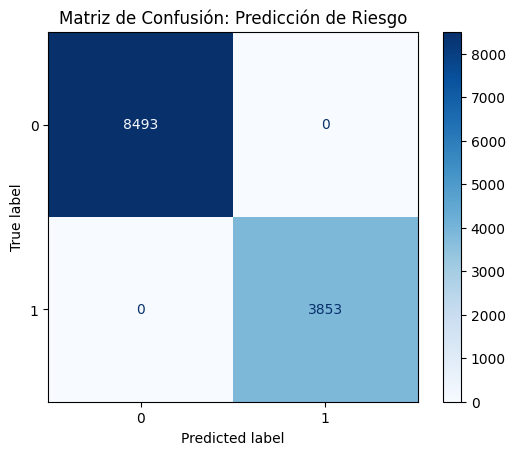

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Selección de Características (Features)
# Convertimos categorías (weather, timeofday) a números usando One-Hot Encoding
X = pd.get_dummies(df[['weather', 'timeofday', 'car', 'pedestrian', 'truck', 'bike']], drop_first=True)
y = df['is_high_risk']

# 2. División Entrenamiento/Prueba (El estándar 80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Entrenamiento
print("Entrenando Random Forest...")
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)

# 4. Evaluación inmediata
print("\n--- REPORTE DE CLASIFICACIÓN ---")
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

# 5. Visualización de Confusión
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Blues')
plt.title("Matriz de Confusión: Predicción de Riesgo")
plt.show()

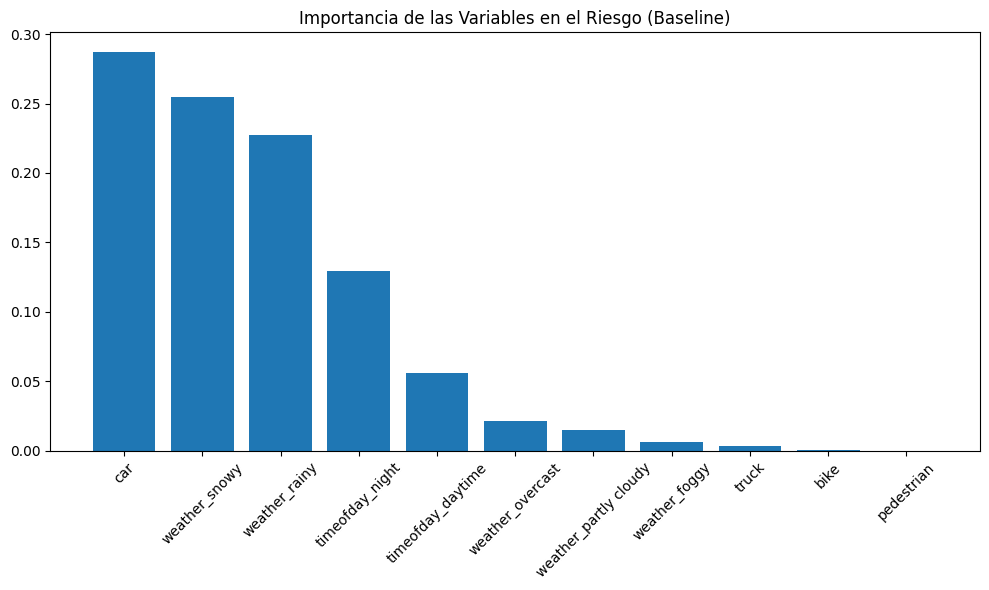

In [7]:
import numpy as np

# Extraer importancia de las variables
importances = model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

# Graficar
plt.figure(figsize=(10, 6))
plt.title("Importancia de las Variables en el Riesgo (Baseline)")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [feature_names[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()

In [9]:
# Buscamos ejemplos interesantes para validar
muestras_lluvia = df[df['weather'] == 'rainy'].index[:2]
muestras_noche = df[df['timeofday'] == 'night'].index[:2]

print(f"Índices de lluvia para revisar: {list(muestras_lluvia)}")
print(f"Índices de noche para revisar: {list(muestras_noche)}")

Índices de lluvia para revisar: [6, 23]
Índices de noche para revisar: [3, 4]


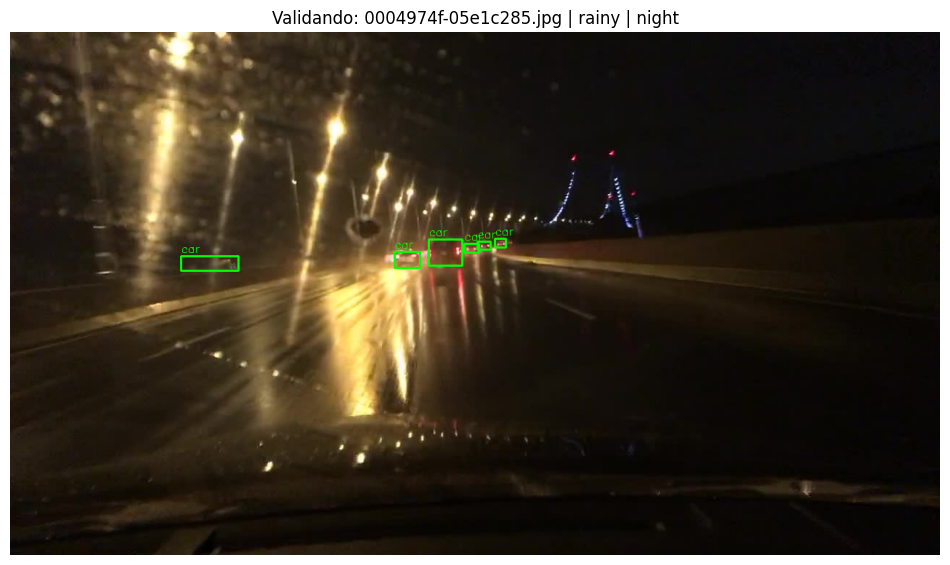

In [10]:
# El Visualizador de Bounding Boxes
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

def visualizar_detecciones(indice):
    # 1. Recuperar info del JSON original
    frame = data[indice]
    img_name = frame['name']
    # Ruta completa a tus imágenes
    base_path = Path(r'D:\samsung_2025_2026\proyectos\object_accident_detection\data\dataset_bdd100k\train\images')
    img_path = base_path / img_name
    
    # 2. Cargar y preparar imagen
    img = cv2.imread(str(img_path))
    if img is None:
        print(f"Error: No se encontró {img_path}")
        return
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # 3. Dibujar cada etiqueta
    for label in frame.get('labels', []):
        if 'box2d' in label:
            box = label['box2d']
            p1 = (int(box['x1']), int(box['y1']))
            p2 = (int(box['x2']), int(box['y2']))
            cat = label['category']
            
            # Color: Verde para carros, Rojo para lo demás
            color = (0, 255, 0) if cat == 'car' else (255, 0, 0)
            cv2.rectangle(img, p1, p2, color, 2)
            cv2.putText(img, cat, (p1[0], p1[1]-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

    # 4. Desplegar
    plt.figure(figsize=(12, 7))
    plt.imshow(img)
    plt.title(f"Validando: {img_name} | {frame['attributes']['weather']} | {frame['attributes']['timeofday']}")
    plt.axis('off')
    plt.show()

# --- PRUEBA DE FUEGO ---
# Cambia el número por uno de los índices que salieron arriba
visualizar_detecciones(muestras_lluvia[0])

In [11]:
import os
from tqdm import tqdm

def convert_to_yolo(data, output_dir):
    # Diccionario de clases (puedes añadir más después)
    classes = {"car": 0, "pedestrian": 1, "truck": 2, "rider": 3, "bicycle": 4}
    
    os.makedirs(output_dir, exist_ok=True)
    img_width, img_height = 1280, 720 # Resolución estándar de BDD100K

    print(f"Generando archivos .txt en {output_dir}...")
    for frame in tqdm(data):
        label_file = os.path.join(output_dir, frame['name'].replace('.jpg', '.txt'))
        
        with open(label_file, 'w') as f:
            for label in frame.get('labels', []):
                cat = label['category']
                if cat in classes and 'box2d' in label:
                    class_id = classes[cat]
                    box = label['box2d']
                    
                    # Convertir de x1,y1,x2,y2 a x_center, y_center, width, height
                    dw = 1.0 / img_width
                    dh = 1.0 / img_height
                    x = (box['x1'] + box['x2']) / 2.0
                    y = (box['y1'] + box['y2']) / 2.0
                    w = box['x2'] - box['x1']
                    h = box['y2'] - box['y1']
                    
                    # Normalizar
                    x, y, w, h = x*dw, y*dh, w*dw, h*dh
                    
                    f.write(f"{class_id} {x:.6f} {y:.6f} {w:.6f} {h:.6f}\n")

# Ejecutamos la conversión
output_labels_path = r'D:\samsung_2025_2026\proyectos\object_accident_detection\data\dataset_bdd100k\train\labels_yolo'
convert_to_yolo(data, output_labels_path)

Generando archivos .txt en D:\samsung_2025_2026\proyectos\object_accident_detection\data\dataset_bdd100k\train\labels_yolo...


100%|██████████| 69863/69863 [00:50<00:00, 1372.76it/s]
